In [1]:
import tensorflow as tf

In [2]:
from tensorflow import keras

In [3]:
print(tf.__version__)

2.1.0


In [4]:
mnist = tf.keras.datasets.mnist
(X_train, y_train),(X_test, y_test) = mnist.load_data()

In [11]:
print(X_train.shape)

(60000, 28, 28)


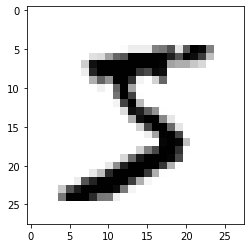

In [7]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0],cmap=plt.cm.binary)
plt.show()

In [8]:
y_train[0]

5

In [9]:
#normalize the data
X_train = tf.keras.utils.normalize(X_train, axis=1)
X_test = tf.keras.utils.normalize(X_test, axis=1)

In [10]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

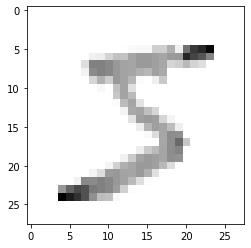

In [11]:
plt.imshow(X_train[0],cmap=plt.cm.binary)
plt.show()

A sequential model just means things are going to go in direct order. A feed forward model. No going backwards

In [12]:
model = tf.keras.models.Sequential()
#now, we divide in into layers #we need to take this 28x28 image, and make it a flat 1x784
model.add(tf.keras.layers.Flatten())

Next, we want our hidden layers. We're going to go with the simplest neural network layer, which is just a Dense layer. 
This refers to the fact that it's a densely-connected layer, meaning it's "fully connected," where each node connects to 
each prior and subsequent node. Just like our image.

This layer has 128 units. The activation function is relu, short for rectified linear. Currently, relu is the activation function you should just default to. There are many more to test for sure, but, if you don't know what to use, use relu to start.

In [13]:
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))

In [14]:
#Let's add another identical layer for good measure
model.add(tf.keras.layers.Dense(128, activation=tf.nn.relu))

In [15]:
#Now, we're ready for an output layer:

model.add(tf.keras.layers.Dense(10, activation=tf.nn.softmax))

This is our final layer. It has 10 nodes. 1 node per possible number prediction. In this case, our activation function is a softmax function, since we're really actually looking for something more like a probability distribution of which of the possible prediction options this thing we're passing features through of is. 

In [16]:
#Initial learning rate, defaults to 1
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Remember why we picked relu as an activation function? Same thing is true for the Adam optimizer. 
#It's just a great default to start with.

Next, we have our loss metric. Loss is a calculation of error. A neural network doesn't actually attempt to maximize accuracy. It attempts to minimize loss. Again, there are many choices, but some form of categorical crossentropy is a good start for a classification task like this.

In [17]:
model.fit(X_train, y_train, epochs=10) #epochs es el numero de iteraciones hasta alcanzar un loss minimo

Train on 60000 samples
Epoch 1/10
60000/60000 [==============================] - 4s 65us/sample - loss: 0.2682 - accuracy: 0.9222
Epoch 2/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.1081 - accuracy: 0.9667
Epoch 3/10
60000/60000 [==============================] - 4s 66us/sample - loss: 0.0738 - accuracy: 0.9772
Epoch 4/10
60000/60000 [==============================] - 4s 63us/sample - loss: 0.0543 - accuracy: 0.9823
Epoch 5/10
60000/60000 [==============================] - 3s 57us/sample - loss: 0.0409 - accuracy: 0.9864
Epoch 6/10
60000/60000 [==============================] - 4s 59us/sample - loss: 0.0337 - accuracy: 0.9887
Epoch 7/10
60000/60000 [==============================] - 4s 63us/sample - loss: 0.0257 - accuracy: 0.9913
Epoch 8/10
60000/60000 [==============================] - 4s 63us/sample - loss: 0.0212 - accuracy: 0.9926
Epoch 9/10
60000/60000 [==============================] - 4s 60us/sample - loss: 0.0187 - accuracy: 0.9933
Epoch 10/10
60

Now that's loss and accuracy for in-sample data. Getting a high accuracy and low loss might mean your model learned how to classify digits in general (it generalized)...or it simply memorized every single example you showed it (it overfit). This is why we need to test on out-of-sample data (data we didn't use to train the model).

In [18]:
val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss)
print(val_acc)

10000/10000 [==============================] - 0s 39us/sample - loss: 0.0992 - accuracy: 0.9760
0.09919836601781772
0.976


In [19]:
#to save the model
model.save('epic_num_reader.model')

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
INFO:tensorflow:Assets written to: epic_num_reader.model\assets


In [20]:
#Load it back:
new_model = tf.keras.models.load_model('epic_num_reader.model')

In [21]:
predictions = new_model.predict(X_test)

In [22]:
import numpy as np
# el numero del 0 al 10 con una mayor prob asociada
print(np.argmax(predictions[0]))
y_test.shape

7


(10000,)

In [23]:
#ahora obtengo el y predecido de verdad
y_pred=np.empty(y_test.shape[0])
for i in range (y_test.shape[0]):
    y_pred[i]=np.argmax(predictions[i])
y_pred.shape

(10000,)

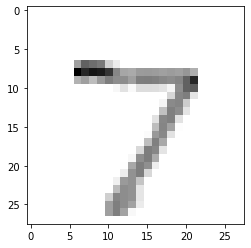

In [24]:
plt.imshow(X_test[0],cmap=plt.cm.binary)
plt.show()

In [25]:
# evaluate the keras model
_, accuracy = model.evaluate(X_test, y_test)
print('Accuracy: %.2f' % (accuracy*100))

10000/10000 [==============================] - 0s 31us/sample - loss: 0.0992 - accuracy: 0.9760
Accuracy: 97.60


In [26]:
# # make probability predictions with the model
# predictions = model.predict(X_test)
# # round predictions 
# rounded = [round(x[0]) for x in predictions]

# make class predictions with the model
predictions = model.predict_classes(X_test)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 969    1    1    1    1    1    1    1    1    3]
 [   1 1131    1    0    0    0    1    0    1    0]
 [   4    3 1002    2    4    1    1    7    7    1]
 [   0    2    4  982    0    7    0    4    5    6]
 [   1    0    3    0  954    0    3    3    0   18]
 [   2    0    0    9    1  873    0    1    2    4]
 [  10    3    0    1    4   15  923    0    2    0]
 [   2    4    6    0    2    0    0 1009    2    3]
 [   8    3    2    4    1    6    2    4  934   10]
 [   3    5    0    0    8    3    0    3    4  983]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.98      0.97       892
           6       0.99      0.96      0.98       958
           7       0.98      0.98   